In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import crystalball

np.random.seed(1234)

## Aim of this exercise
1. Understand the idea of CIs using Neyman construction
2. Check the CIs for Symmetric response, tail on one side and (3) wider distribution on one side with double sided gaussian
3. What do you notice in all the 3 cases?
4. What coverage do you see?


In [2]:
m_true = 125.0
#response = "gaus"
#response = "cb"
response = "dcb"

In [3]:
### Gaussian detector response
def gaussian_response(mtrue, sigma, N):
    return np.random.normal(mtrue, sigma, N)

In [4]:
### Crystal Ball detector response
def crystalball_response(mtrue, sigma, alpha=1.5, n=3, N=100):

    x = crystalball.rvs(beta=alpha,
                        m=n,
                        loc=mtrue,
                        scale=sigma,
                        size=N)

    return x

In [5]:
### Two sided asymmetric gaussian
def cruijff_response(mtrue,
                     sigmaL,
                     sigmaR,
                     N):

    x = np.random.randn(N)

    reco = np.empty(N)

    mask = x<0

    reco[mask] = mtrue + sigmaL*x[mask]

    reco[~mask] = mtrue + sigmaR*x[~mask]

    return reco

(array([ 1.,  2.,  6., 10.,  6., 11., 14.,  9., 20., 26., 43., 24., 33.,
        32., 30., 15., 18., 16., 16.,  9., 15., 16., 14., 13., 13., 10.,
         7.,  8.,  4.,  6.,  7.,  6.,  8.,  4.,  1.,  4.,  1.,  4.,  4.,
         2.,  2.,  3.,  2.,  2.,  0.,  1.,  0.,  0.,  0.,  2.]),
 array([121.70988463, 121.93821996, 122.1665553 , 122.39489063,
        122.62322597, 122.85156131, 123.07989664, 123.30823198,
        123.53656731, 123.76490265, 123.99323798, 124.22157332,
        124.44990865, 124.67824399, 124.90657932, 125.13491466,
        125.36324999, 125.59158533, 125.81992066, 126.048256  ,
        126.27659133, 126.50492667, 126.733262  , 126.96159734,
        127.18993267, 127.41826801, 127.64660334, 127.87493868,
        128.10327401, 128.33160935, 128.55994468, 128.78828002,
        129.01661535, 129.24495069, 129.47328602, 129.70162136,
        129.9299567 , 130.15829203, 130.38662737, 130.6149627 ,
        130.84329804, 131.07163337, 131.29996871, 131.52830404,
        131.

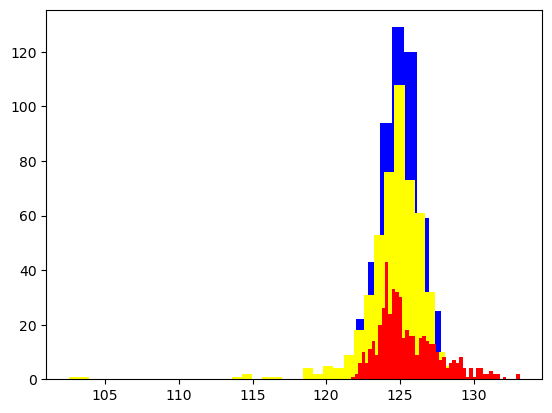

In [6]:
### Generate 500 pseudo experiment using Gaussian/CB or Cruijff and look at the Higgs mass. 
Nevents = 500

sigma_detector = 1.3

### write the code here
gaussian_events = gaussian_response(125,1.3,500)
plt.hist(gaussian_events, bins=10, color ='blue')

cb_events = crystalball_response(125, 1.3, alpha=1.5, n=3, N=500)
plt.hist(cb_events,bins=40, color ='yellow')

cruijff_events = cruijff_response(125, 1.3, 2.6, 500)
plt.hist(cruijff_events,bins=50, color ='red')

(array([  1.,   0.,   1.,   1.,   2.,   3.,   1.,   0.,   2.,   4.,   5.,
          8.,  11.,  16.,  23.,  27.,  41.,  49.,  44.,  48.,  76.,  72.,
         87., 117., 112., 155., 154., 173., 163., 204., 208., 214., 222.,
        237., 106.,  96., 124., 100., 117., 113., 115., 102.,  88.,  99.,
         91.,  85.,  87.,  67.,  86.,  85.,  74.,  78.,  72.,  68.,  68.,
         60.,  47.,  56.,  36.,  44.,  37.,  28.,  30.,  20.,  29.,  26.,
         17.,  25.,  20.,  12.,  16.,  13.,   9.,  10.,  10.,   8.,   5.,
          4.,   8.,   5.,   3.,   1.,   4.,   2.,   0.,   4.,   5.,   0.,
          1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.]),
 array([120.04477487, 120.19056947, 120.33636408, 120.48215869,
        120.6279533 , 120.77374791, 120.91954251, 121.06533712,
        121.21113173, 121.35692634, 121.50272095, 121.64851555,
        121.79431016, 121.94010477, 122.08589938, 122.23169399,
        122.37748859, 122.5232832 , 122.66907781, 122.81487242

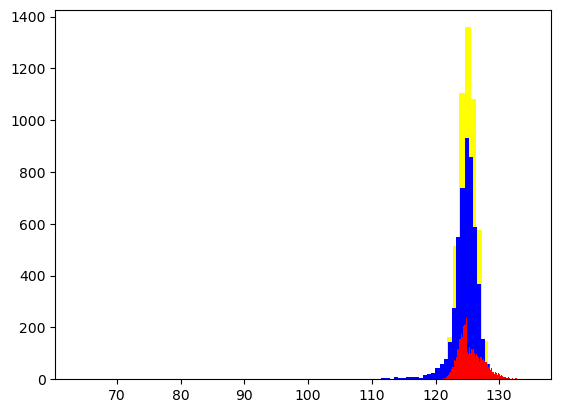

In [7]:
### Now generate 5000 pseudoexperiments.
gaussian_events1 = gaussian_response(125,1.3,5000)
plt.hist(gaussian_events1, bins=10, color ='yellow')

cb_events1 = crystalball_response(125, 1.3, alpha=1.5, n=3, N=5000)
plt.hist(cb_events1,bins=100, color ='blue')

cruijff_events1 = cruijff_response(125, 1.3, 2.6, 5000)
plt.hist(cruijff_events1,bins=100, color ='red')



In [8]:
### plot the reconstructed Mass


In [9]:
### Write the classical CI
gaussian_mean = np.mean(gaussian_events1)
print("gaussian mean =",gaussian_mean)

cb_mean = np.mean(cb_events1)
print("crystall mean =",cb_mean)

cruijff_mean = np.mean(cruijff_events1)
print("two sided assym gaussian mean =",cruijff_mean)




gaussian mean = 125.02791160192606
crystall mean = 124.59679837251015
two sided assym gaussian mean = 125.54561016441794


gaussian mean = 125.00098008634373
123.68442601994575
126.3062396015644
cb mean = 124.59752342487394
123.37093860181439
126.2172420248898
cruijff mean = 125.5298883906595
123.73065258270097
127.61913692750157


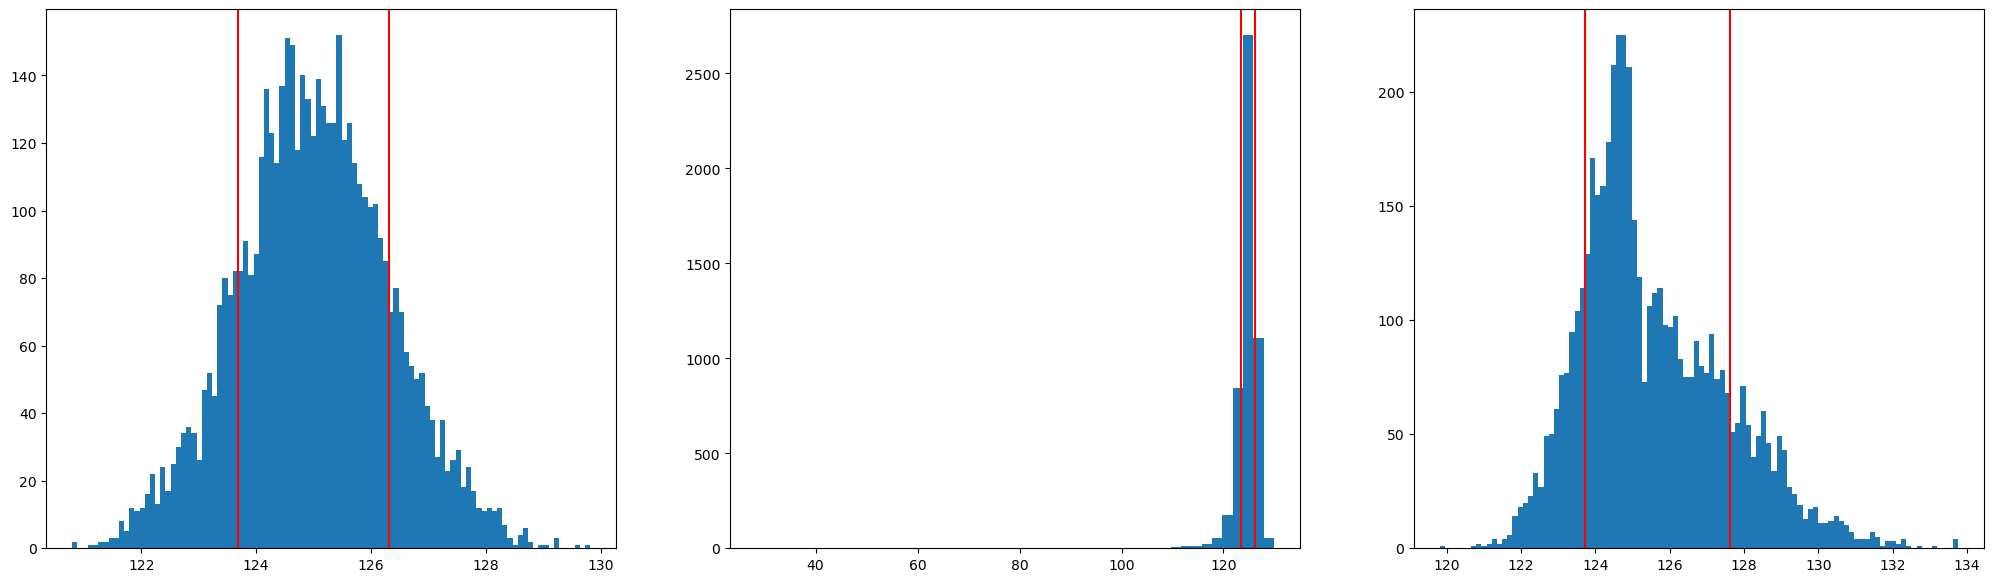

In [17]:
### plot the lines of CI on the histogram
plt.figure(figsize=(25, 7))

plt.subplot(1, 3, 1)
gaussian_events1 = gaussian_response(125,1.3,5000)
plt.hist(gaussian_events1, bins=100)
gaussian_mean = np.mean(gaussian_events1)
print("gaussian mean =",gaussian_mean)
left_CI= np.percentile(gaussian_events1,15.85)
print(left_CI)
right_CI= np.percentile(gaussian_events1,84.15)
print(right_CI)
plt.axvline(left_CI, color ="red")
plt.axvline(right_CI, color ="red")

plt.subplot(1, 3, 2)
cb_events1 = crystalball_response(125, 1.3, alpha=1.5, n=3, N=5000)
plt.hist(cb_events1,bins=50)

cb_mean = np.mean(cb_events1)
print("cb mean =",cb_mean)
left_CI_cb= np.percentile(cb_events1,15.85)
print(left_CI_cb)
right_CI_cb= np.percentile(cb_events1,84.15)
print(right_CI_cb)

plt.axvline(left_CI_cb, color ="red")
plt.axvline(right_CI_cb, color ="red")

plt.subplot(1, 3, 3)
cruijff_events1 = cruijff_response(125, 1.3, 2.6, 5000)
plt.hist(cruijff_events1,bins=100)

cruijff_mean = np.mean(cruijff_events1)
print("cruijff mean =",cruijff_mean)

left_CI_cr= np.percentile(cruijff_events1,15.85)
print(left_CI_cr)

right_CI_cr= np.percentile(cruijff_events1,84.15)
print(right_CI_cr)

plt.axvline(left_CI_cr, color ="red")
plt.axvline(right_CI_cr, color ="red")



Text(0, 0.5, 'Reconstructed Mass')

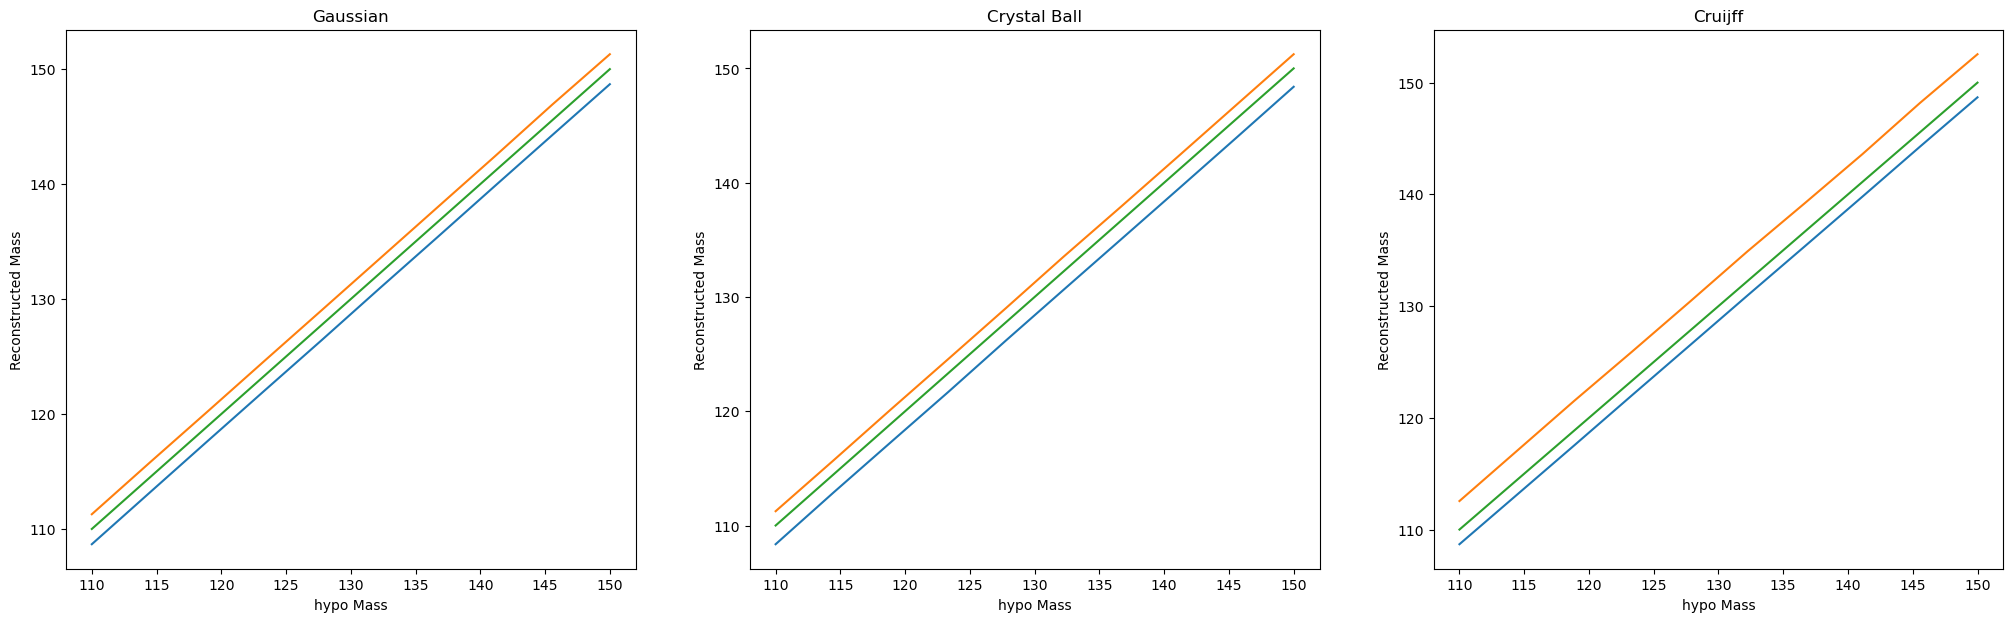

In [35]:
#Build Neyman belt: For each Hypothesised mass, generate the reconstructed mass: Consider generating 
# Hypothesised masses from 110 to 150 GeV
## Check what happens if you generate from 124 to 127 (in terms of coverage probabiliy)
trueMasses = np.linspace(110, 150,10)

plt.figure(figsize=(25, 7))

plt.subplot(1,3,1)
lower = []
upper = []

for mt in trueMasses:
    reco = gaussian_response(mt, 1.3, 10000)

    lower.append(np.percentile(reco, 15.85))
    upper.append(np.percentile(reco, 84.15))

plt.plot(trueMasses, lower)
plt.plot(trueMasses, upper)
plt.plot(trueMasses, trueMasses, label="True Mass")

plt.title("Gaussian")
plt.xlabel("hypo Mass")
plt.ylabel("Reconstructed Mass")

plt.subplot(1,3,2)
lower = []
upper = []

for mt in trueMasses:
    reco = crystalball_response(mt, 1.3, alpha=1.5, n=3, N=10000)
    lower.append(np.percentile(reco, 15.85))
    upper.append(np.percentile(reco, 84.15))

plt.plot(trueMasses, lower)
plt.plot(trueMasses, upper)
plt.plot(trueMasses, trueMasses)

plt.title("Crystal Ball")
plt.xlabel("hypo Mass")
plt.ylabel("Reconstructed Mass")

plt.subplot(1,3,3)
lower = []
upper = []

for mt in trueMasses:
    reco = cruijff_response(mt, 1.3, 2.6, 10000)
    lower.append(np.percentile(reco, 15.85))
    upper.append(np.percentile(reco, 84.15))

plt.plot(trueMasses, lower)
plt.plot(trueMasses, upper)
plt.plot(trueMasses, trueMasses)

plt.title("Cruijff")
plt.xlabel("hypo Mass")
plt.ylabel("Reconstructed Mass")


In [12]:
#lower=[]

#upper=[]

Text(0, 0.5, 'Reconstructed Mass')

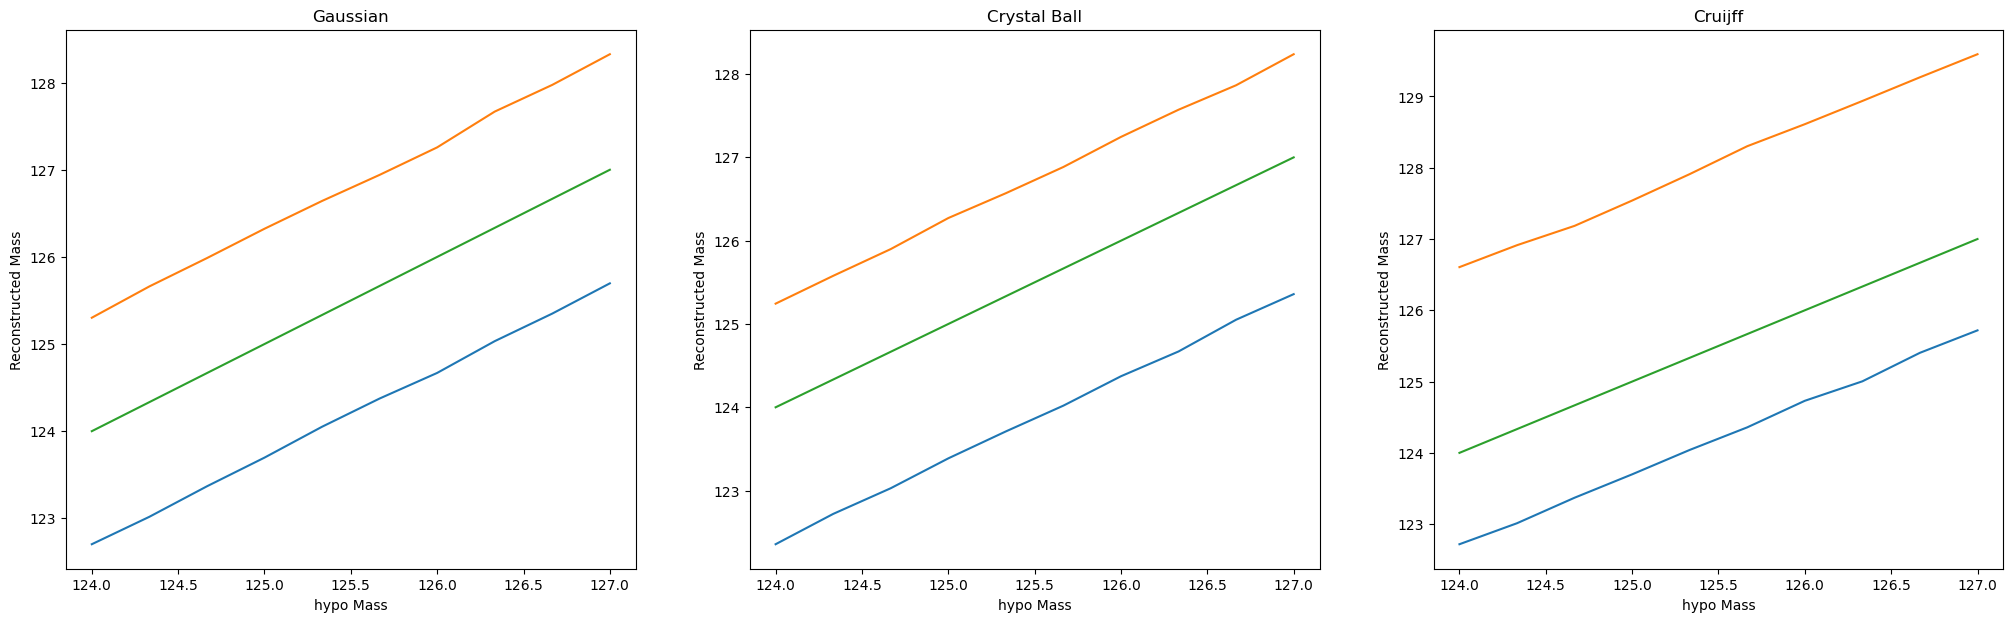

In [33]:
# Belt construction: sample the distribution of the estimator
# at each true mass value.
# The estimator here is a single measurement (mhat = reco[0]),
# so we sample many single measurements from the response function.

#Ntoys_belt = 10000   # single measurements per belt point

### For each of the true mass#Build Neyman belt: For each Hypothesised mass, generate the reconstructed mass: Consider generating 
# Hypothesised masses from 110 to 150 GeV
## Check what happens if you generate from 124 to 127 (in terms of coverage probabiliy) Hypothesis
#for mt in trueMasses:

### Write here

#Build Neyman belt: For each Hypothesised mass, generate the reconstructed mass: Consider generating 
# Hypothesised masses from 110 to 150 GeV
## Check what happens if you generate from 124 to 127 (in terms of coverage probabiliy)
trueMasses = np.linspace(124, 127, 10)

plt.figure(figsize=(25, 7))

plt.subplot(1,3,1)
lower = []
upper = []

for mt in trueMasses:
    reco = gaussian_response(mt, 1.3, 10000)

    lower.append(np.percentile(reco, 15.85))
    upper.append(np.percentile(reco, 84.15))

plt.plot(trueMasses, lower)
plt.plot(trueMasses, upper)
plt.plot(trueMasses, trueMasses, label="True Mass")

plt.title("Gaussian")
plt.xlabel("hypo Mass")
plt.ylabel("Reconstructed Mass")

plt.subplot(1,3,2)
lower = []
upper = []

for mt in trueMasses:
    reco = crystalball_response(mt, 1.3, alpha=1.5, n=3, N=10000)
    lower.append(np.percentile(reco, 15.85))
    upper.append(np.percentile(reco, 84.15))

plt.plot(trueMasses, lower)
plt.plot(trueMasses, upper)
plt.plot(trueMasses, trueMasses)

plt.title("Crystal Ball")
plt.xlabel("hypo Mass")
plt.ylabel("Reconstructed Mass")

plt.subplot(1,3,3)
lower = []
upper = []

for mt in trueMasses:
    reco = cruijff_response(mt, 1.3, 2.6, 10000)
    lower.append(np.percentile(reco, 15.85))
    upper.append(np.percentile(reco, 84.15))

plt.plot(trueMasses, lower)
plt.plot(trueMasses, upper)
plt.plot(trueMasses, trueMasses)

plt.title("Cruijff")
plt.xlabel("hypo Mass")
plt.ylabel("Reconstructed Mass")
   

In [ ]:
### plot Neyman belt and also plot the slope = 1 line to visualize whether the intervals are symmetric or asymmetric 




In [ ]:
### invert the neyman belt to get the CI on mobs = 125 GeV

In [ ]:
### plot that mobs = 125 GeV on the Neyman belt

In [ ]:
### coverage test
### Full Neyman coverage test
